In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

random.seed(123)

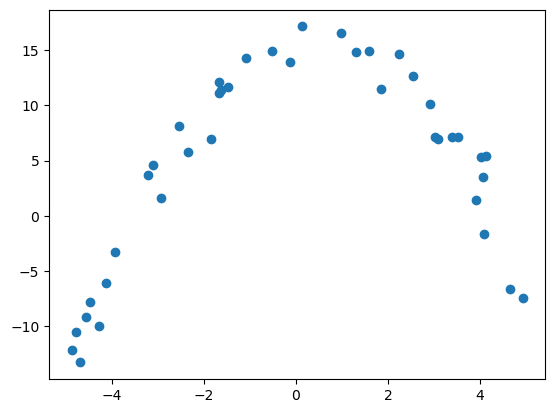

In [3]:
coefs = [15,1,-1]

def polynomial(coefs, x):
    n = len(coefs)
    return sum([coefs[i]*x**i for i in range(n)])

X = []
Y = []
for i in range(40):
    x = random.uniform(-5,5)
    y = polynomial(coefs, x) + random.gauss(0,2)
    X.append(x)
    Y.append(y)

plt.scatter(X,Y)
plt.show()

In [4]:
data = pd.DataFrame({'Y':Y, 'X':X})
for _ in range(2,200):
    data['X'+str(_)] = data['X']**_
data.head()

C:\Users\isaac\AppData\Local\Temp\ipykernel_13680\2791746485.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['X'+str(_)] = data['X']**_
C:\Users\isaac\AppData\Local\Temp\ipykernel_13680\2791746485.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['X'+str(_)] = data['X']**_
C:\Users\isaac\AppData\Local\Temp\ipykernel_13680\2791746485.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

,Y,X,X2,X3,X4,X5,X6,X7,X8,X9,...,X190,X191,X192,X193,X194,X195,X196,X197,X198,X199
0,-7.768090,-4.476364,20.037835,-89.696642,401.514822,-1797.326499,8045.487658,-36014.531409,161214.152289,-721653.229449,...,4.740511e+123,-2.122025e+124,9.498957e+124,-4.252079e+125,1.903385e+126,-8.520246e+126,3.813972e+127,-1.707273e+128,7.642374e+128,-3.421005e+129
1,-3.247614,-3.922998,15.389911,-60.374583,236.849347,-929.159433,3645.090272,-14299.680573,56097.613294,-220070.805157,...,6.129558e+112,-2.404624e+113,9.433334e+113,-3.700695e+114,1.451782e+115,-5.695336e+115,2.234279e+116,-8.765072e+116,3.438535e+117,-1.348937e+118
2,5.324240,4.011989,16.096054,64.577188,259.082953,1039.437902,4170.213198,16730.848560,67123.976695,269300.641335,...,4.348554e+114,1.744635e+115,6.999456e+115,2.808174e+116,1.126636e+117,4.520052e+117,1.813440e+118,7.275500e+118,2.918922e+119,1.171068e+120
3,11.094870,-1.678023,2.815761,-4.724912,7.928511,-13.304225,22.324795,-37.461520,62.861292,-105.482695,...,5.147585e+42,-8.637765e+42,1.449437e+43,-2.432188e+43,4.081268e+43,-6.848462e+43,1.149188e+44,-1.928363e+44,3.235838e+44,-5.429811e+44
4,7.099583,3.520866,12.396499,43.646413,153.673181,541.062706,1905.009387,6707.283141,23615.446432,83146.826887,...,7.301445e+103,2.570741e+104,9.051235e+104,3.186819e+105,1.122036e+106,3.950539e+106,1.390932e+107,4.897286e+107,1.724269e+108,6.070920e+108


c:\Users\isaac\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.143e+01, tolerance: 2.574e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\isaac\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


(-20.0, 20.0)

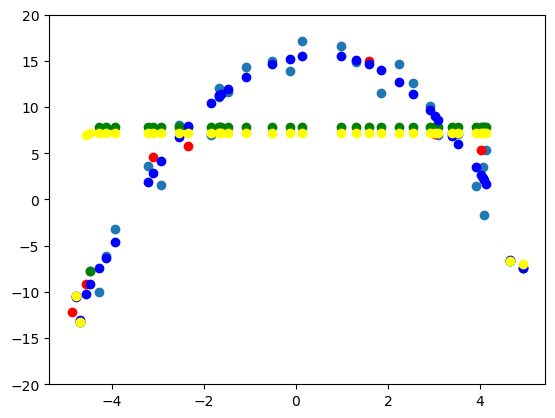

In [8]:
train, test = train_test_split(data, test_size=0.2)
X_train = train.drop('Y', axis=1)
X_test = test.drop('Y', axis=1)

linear = LinearRegression()
linear1 = Lasso(alpha = 0.1)
linear2 = Ridge(alpha = 0.1)

linear.fit(X_train, train['Y'])
linear1.fit(X_train, train['Y'])
linear2.fit(X_train, train['Y'])

predit = data.drop('Y', axis=1)
pred_y = linear.predict(predit)
pred_y1 = linear1.predict(predit)
pred_y2 = linear2.predict(predit)

plt.scatter(train['X'], train['Y'])
plt.scatter(test['X'], test['Y'], color='red')
plt.scatter(predit['X'], pred_y, color='green')
plt.scatter(predit['X'], pred_y1, color='blue')
plt.scatter(predit['X'], pred_y2, color='yellow')
plt.ylim(-20, 20)
